# CO3133 - Text-Image Classification with N24News

Notebook này triển khai bài toán **multimodal news classification** trên `N24News`.
Đầu vào của mỗi mẫu là **ảnh bài báo + văn bản bài báo**, đầu ra là **nhãn chuyên mục tin tức**.
Hai mô hình được so sánh là `CLIP` và `VisualBERT`.


### Dependency Setup

Cell dưới đây cài các thư viện cần thiết để notebook có thể chạy trên một máy mới.


In [1]:
# Run this cell only if your environment is missing the required packages.
%pip install -q pandas numpy matplotlib seaborn pillow scikit-learn     torch torchvision torchaudio transformers accelerate gdown tqdm


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: C:\Users\HAD\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


### Import Libraries And Resolve Paths

Cell này import các thư viện chính và tự động dò thư mục `btl1/` mà không phụ thuộc vào `GPT.md` hay file ngoài luồng.


In [2]:
from __future__ import annotations

import json
import random
import shutil
import re
import tarfile
import zipfile
from pathlib import Path
from typing import Iterable

import gdown
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from PIL import Image
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from torch import nn
from torch.optim import AdamW
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm
from transformers import (
    AutoImageProcessor,
    AutoProcessor,
    AutoTokenizer,
    CLIPModel,
    CLIPVisionModel,
    VisualBertConfig,
    VisualBertModel,
    get_linear_schedule_with_warmup,
)


def find_btl1_root(start: Path) -> Path:
    start = start.resolve()
    for path in [start, *start.parents]:
        if path.name == "btl1" and (path / "notebooks").exists():
            return path
        candidate = path / "btl1"
        if candidate.exists() and (candidate / "notebooks").exists():
            return candidate
    raise FileNotFoundError("Could not locate the btl1/ directory from the current working directory.")


BTL1_ROOT = find_btl1_root(Path.cwd())
REPO_ROOT = BTL1_ROOT.parent
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"BTL1 root: {BTL1_ROOT}")
print(f"Repo root: {REPO_ROOT}")
print(f"Device: {DEVICE}")


C:\Users\HAD\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


BTL1 root: D:\DeepLearning\btl1
Repo root: D:\DeepLearning
Device: cuda


### Configure Dataset Paths And Experiment Settings

Cell này định nghĩa nơi đặt `source/raw/processed/artifacts`, link Google Drive của `N24News`, quy ước đặt tên `train/val/test` cho nội bộ repo và các siêu tham số cho `CLIP` và `VisualBERT`.


In [3]:
N24_DIR = BTL1_ROOT / "data" / "multimodal" / "n24news"
SOURCE_DIR = N24_DIR / "source"
RAW_DIR = N24_DIR / "raw"
PROCESSED_DIR = N24_DIR / "processed"
ARTIFACT_DIR = BTL1_ROOT / "artifacts" / "multimodal"
REPORT_MEDIA_DIR = BTL1_ROOT / "reports" / "media"
HARD_CASE_DIR = REPORT_MEDIA_DIR / "n24news-hard-cases"
HARD_CASE_MANIFEST_PATH = HARD_CASE_DIR / "manifest.json"

N24NEWS_DRIVE_URL = "https://drive.google.com/file/d/1OS1fXwZ1Vsj70lEQajccyssxQRYp5X9D/view?usp=share_link"
N24NEWS_DRIVE_FILE_ID = "1OS1fXwZ1Vsj70lEQajccyssxQRYp5X9D"
OFFICIAL_REPO_URL = "https://github.com/billywzh717/N24News"
PAPER_URL = "https://aclanthology.org/2022.lrec-1.729/"

SEED = 42
VAL_RATIO = 0.10
TEST_RATIO = 0.20
TAIL_FOCUS_CLASSES = ["Well", "Style", "Education", "Your Money"]
HARD_CASES_PER_CLASS = 2
PREVIEW_VERSION = "20260325a"
MIN_TEXT_CHARS = 40
TOP_K_CLASSES = None  # Set an integer to keep only the most frequent classes.
MAX_SAMPLES = None  # Set an integer for a smaller debug subset.
DOWNLOAD_IF_MISSING = True
REBUILD_PROCESSED = False
REUSE_CHECKPOINT_IF_AVAILABLE = True
NUM_WORKERS = 0  # Keep Windows-friendly dataloaders.

CLIP_CFG = {
    "backbone": "openai/clip-vit-base-patch32",
    "batch_size": 8 if torch.cuda.is_available() else 4,
    "epochs": 2,
    "lr": 1e-5,
    "weight_decay": 0.01,
    "dropout": 0.2,
    "max_text_length": 77,
    "warmup_ratio": 0.1,
    "patience": 2,
}

VB_CFG = {
    "visualbert_backbone": "uclanlp/visualbert-vqa-coco-pre",
    "vision_backbone": "openai/clip-vit-base-patch32",
    "tokenizer_name": "bert-base-uncased",
    "batch_size": 4 if torch.cuda.is_available() else 2,
    "epochs": 2,
    "lr": 1e-5,
    "weight_decay": 0.01,
    "dropout": 0.2,
    "max_text_length": 256,
    "max_visual_tokens": 32,
    "warmup_ratio": 0.1,
    "patience": 2,
}

for folder in [SOURCE_DIR, RAW_DIR, PROCESSED_DIR, ARTIFACT_DIR, REPORT_MEDIA_DIR, HARD_CASE_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print(f"Source directory: {SOURCE_DIR}")
print(f"Raw directory: {RAW_DIR}")
print(f"Processed directory: {PROCESSED_DIR}")
print(f"Artifact directory: {ARTIFACT_DIR}")
print(f"Hard-case preview directory: {HARD_CASE_DIR}")


Source directory: D:\DeepLearning\btl1\data\multimodal\n24news\source
Raw directory: D:\DeepLearning\btl1\data\multimodal\n24news\raw
Processed directory: D:\DeepLearning\btl1\data\multimodal\n24news\processed
Artifact directory: D:\DeepLearning\btl1\artifacts\multimodal
Hard-case preview directory: D:\DeepLearning\btl1\reports\media\n24news-hard-cases


### Helper Functions For Data Acquisition And Parsing

Cell này xử lý tải dữ liệu, giải nén archive, tìm manifest JSON, lập chỉ mục ảnh và hợp nhất văn bản bài báo.


In [4]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(SEED)


IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".webp"}
ARCHIVE_SUFFIXES = (".zip", ".tar", ".tar.gz", ".tgz")
CATEGORY_KEYS = ("category", "label", "class", "section", "topic")
IMAGE_KEYS = ("image_id", "img_id", "image", "imageid", "img")
HEADLINE_KEYS = ("headline", "title")
ABSTRACT_KEYS = ("abstract", "summary", "snippet", "lead")
BODY_KEYS = ("body", "article", "maintext", "text", "content")
CAPTION_KEYS = ("caption", "image_caption")
ID_KEYS = ("article_id", "news_id", "id", "doc_id")


def normalize_space(text: str) -> str:
    text = text.replace("\n", " ").replace("\r", " ")
    return re.sub(r"\s+", " ", text).strip()


def pick_field(record: dict, keys: Iterable[str]) -> str:
    for key in keys:
        value = record.get(key)
        if isinstance(value, str) and normalize_space(value):
            return normalize_space(value)
        if isinstance(value, (int, float)):
            return str(value)
    return ""


def extract_records(payload) -> list[dict]:
    if isinstance(payload, list):
        return [item for item in payload if isinstance(item, dict)]
    if isinstance(payload, dict):
        for key in ["data", "items", "articles", "news", "records", "dataset"]:
            value = payload.get(key)
            if isinstance(value, list) and value and isinstance(value[0], dict):
                return value
        if payload and all(isinstance(v, dict) for v in payload.values()):
            return list(payload.values())
    return []


def record_score(record: dict) -> int:
    score = 0
    if pick_field(record, CATEGORY_KEYS):
        score += 3
    if pick_field(record, IMAGE_KEYS):
        score += 3
    if pick_field(record, HEADLINE_KEYS):
        score += 2
    if pick_field(record, BODY_KEYS) or pick_field(record, ABSTRACT_KEYS):
        score += 2
    return score


def download_from_drive_if_missing() -> None:
    archives = [path for path in SOURCE_DIR.iterdir() if path.is_file()]
    if archives:
        print("Source file already exists. Skipping Google Drive download.")
        return
    if not DOWNLOAD_IF_MISSING:
        raise FileNotFoundError(
            "N24News source file is missing. Place the downloaded archive or extracted files in "
            "btl1/data/multimodal/n24news/source/."
        )
    print("Downloading N24News from Google Drive...")
    gdown.download(url=N24NEWS_DRIVE_URL, output=str(SOURCE_DIR), fuzzy=True, quiet=False)


def find_archives(folder: Path) -> list[Path]:
    files = []
    for path in folder.iterdir():
        if not path.is_file():
            continue
        if path.name.lower().endswith(ARCHIVE_SUFFIXES):
            files.append(path)
    return sorted(files)


def extract_archive(archive_path: Path, target_dir: Path) -> None:
    marker_files = list(target_dir.rglob("*.json")) + list(target_dir.rglob("*.jpg"))
    if marker_files:
        print(f"Raw directory already contains extracted data. Skipping extraction for {archive_path.name}.")
        return

    print(f"Extracting {archive_path.name}...")
    if archive_path.name.lower().endswith(".zip"):
        with zipfile.ZipFile(archive_path, "r") as zf:
            zf.extractall(target_dir)
    elif archive_path.name.lower().endswith((".tar.gz", ".tgz", ".tar")):
        mode = "r:gz" if archive_path.name.lower().endswith((".tar.gz", ".tgz")) else "r"
        with tarfile.open(archive_path, mode) as tf:
            tf.extractall(target_dir)
    else:
        raise ValueError(f"Unsupported archive format: {archive_path}")
    print("Extraction complete.")


def ensure_raw_data_available() -> None:
    if list(RAW_DIR.rglob("*.json")) and list(RAW_DIR.rglob("*.jpg")):
        print("Raw N24News data already available.")
        return

    source_json = list(SOURCE_DIR.rglob("*.json"))
    source_images = []
    for ext in IMAGE_EXTENSIONS:
        source_images.extend(SOURCE_DIR.rglob(f"*{ext}"))
    if source_json and source_images:
        print("Detected extracted source data. Using files directly from source/.")
        return

    download_from_drive_if_missing()
    archives = find_archives(SOURCE_DIR)
    if not archives:
        raise FileNotFoundError(
            "No N24News archive was found in source/. Place the downloaded file there or enable auto-download."
        )
    for archive in archives:
        extract_archive(archive, RAW_DIR)


def candidate_data_roots() -> list[Path]:
    roots = []
    if RAW_DIR.exists():
        roots.append(RAW_DIR)
    if SOURCE_DIR.exists():
        roots.append(SOURCE_DIR)
    return roots


def find_manifest_path() -> Path:
    candidates = []
    for root in candidate_data_roots():
        for json_path in root.rglob("*.json"):
            try:
                payload = json.loads(json_path.read_text(encoding="utf-8"))
            except Exception:
                try:
                    payload = json.loads(json_path.read_text(encoding="latin-1"))
                except Exception:
                    continue
            records = extract_records(payload)
            if not records:
                continue
            scores = [record_score(item) for item in records[: min(len(records), 200)]]
            score = sum(scores) / max(len(scores), 1)
            candidates.append((score, len(records), json_path))
    if not candidates:
        raise FileNotFoundError(
            "Could not locate a usable N24News json manifest. Check the downloaded dataset layout."
        )
    candidates.sort(reverse=True)
    best = candidates[0][2]
    print(f"Using manifest: {best}")
    return best


def load_manifest_records(manifest_path: Path) -> list[dict]:
    try:
        payload = json.loads(manifest_path.read_text(encoding="utf-8"))
    except UnicodeDecodeError:
        payload = json.loads(manifest_path.read_text(encoding="latin-1"))
    records = extract_records(payload)
    if not records:
        raise RuntimeError(f"Manifest file {manifest_path} did not contain a usable list of article records.")
    return records


def build_image_index() -> dict[str, str]:
    image_files = []
    for root in candidate_data_roots():
        for ext in IMAGE_EXTENSIONS:
            image_files.extend(root.rglob(f"*{ext}"))
    if not image_files:
        raise FileNotFoundError("No image files were found for N24News.")

    index = {}
    for path in sorted(image_files):
        stem = path.stem
        rel_path = path.relative_to(REPO_ROOT).as_posix() if REPO_ROOT in path.parents else path.relative_to(BTL1_ROOT).as_posix()
        index.setdefault(stem, rel_path)
    print(f"Indexed {len(index):,} unique image stems.")
    return index


def compose_text(record: dict) -> tuple[str, dict[str, str]]:
    headline = pick_field(record, HEADLINE_KEYS)
    abstract = pick_field(record, ABSTRACT_KEYS)
    body = pick_field(record, BODY_KEYS)
    caption = pick_field(record, CAPTION_KEYS)

    blocks = []
    if headline:
        blocks.append(f"Headline: {headline}")
    if abstract:
        blocks.append(f"Abstract: {abstract}")
    if body:
        blocks.append(f"Body: {body}")
    if caption:
        blocks.append(f"Caption: {caption}")

    return "\n".join(blocks).strip(), {
        "headline": headline,
        "abstract": abstract,
        "body": body,
        "caption": caption,
    }


### Build The Processed Train Val Test Splits

Cell này kiểm tra dữ liệu raw, parse article record, ghép `image + text`, lọc mẫu lỗi và chuẩn hóa thành `train/val/test`. Nếu package gốc cung cấp `train/dev/test`, notebook sẽ ánh xạ `dev` của package thành `val` trong toàn bộ file processed và quá trình huấn luyện.


In [5]:
base_columns = [
    "article_id",
    "image_id",
    "category",
    "label_id",
    "text_input",
    "headline",
    "abstract",
    "body",
    "caption",
    "image_relpath",
    "text_chars",
]

split_paths = {
    "train": PROCESSED_DIR / "train.csv",
    "val": PROCESSED_DIR / "val.csv",
    "test": PROCESSED_DIR / "test.csv",
}

official_split_map = {
    "train": "train",
    "val": "dev",
    "test": "test",
}

def build_rows_from_records(records: list[dict], image_index: dict[str, str], split_name: str) -> list[dict]:
    rows = []
    for idx, record in enumerate(tqdm(records, desc=f"Parsing {split_name} records")):
        category = pick_field(record, CATEGORY_KEYS)
        image_id = pick_field(record, IMAGE_KEYS)
        article_id = pick_field(record, ID_KEYS) or f"{split_name}_{idx}"
        text_input, text_parts = compose_text(record)

        if not category or not image_id or len(text_input) < MIN_TEXT_CHARS:
            continue

        image_relpath = image_index.get(Path(str(image_id)).stem)
        if image_relpath is None:
            continue

        rows.append({
            "article_id": article_id,
            "image_id": str(image_id),
            "category": category,
            "text_input": text_input,
            "headline": text_parts["headline"],
            "abstract": text_parts["abstract"],
            "body": text_parts["body"],
            "caption": text_parts["caption"],
            "image_relpath": image_relpath,
            "text_chars": len(text_input),
        })
    return rows

if all(path.exists() for path in split_paths.values()) and not REBUILD_PROCESSED:
    train_df = pd.read_csv(split_paths["train"])
    val_df = pd.read_csv(split_paths["val"])
    test_df = pd.read_csv(split_paths["test"])
    label_mapping = (
        pd.concat([train_df[["label_id", "category"]], val_df[["label_id", "category"]], test_df[["label_id", "category"]]])
        .drop_duplicates()
        .sort_values("label_id")
    )
    label_names = label_mapping["category"].tolist()
    print("Loaded existing processed splits.")
else:
    ensure_raw_data_available()
    image_index = build_image_index()

    official_split_files = {}
    for root in candidate_data_roots():
        for internal_name, official_name in official_split_map.items():
            split_file = next(root.rglob(f"nytimes_{official_name}.json"), None)
            if split_file is not None:
                official_split_files[internal_name] = split_file

    if len(official_split_files) == 3:
        print("Using official N24News train/val/test files with internal naming train/val/test.")
        train_records = load_manifest_records(official_split_files["train"])
        val_records = load_manifest_records(official_split_files["val"])
        test_records = load_manifest_records(official_split_files["test"])

        train_df = pd.DataFrame(build_rows_from_records(train_records, image_index, "train"))
        val_df = pd.DataFrame(build_rows_from_records(val_records, image_index, "val"))
        test_df = pd.DataFrame(build_rows_from_records(test_records, image_index, "test"))
        combined_df = pd.concat([train_df, val_df, test_df], ignore_index=True)
    else:
        manifest_path = find_manifest_path()
        records = load_manifest_records(manifest_path)
        combined_df = pd.DataFrame(build_rows_from_records(records, image_index, "full"))
        if combined_df.empty:
            raise RuntimeError("No valid multimodal records were parsed from N24News.")

        category_counts = combined_df["category"].value_counts()
        if TOP_K_CLASSES is not None:
            keep_categories = category_counts.head(TOP_K_CLASSES).index.tolist()
            combined_df = combined_df[combined_df["category"].isin(keep_categories)].reset_index(drop=True)
            print(f"Keeping top-{TOP_K_CLASSES} categories.")

        if MAX_SAMPLES is not None and len(combined_df) > MAX_SAMPLES:
            combined_df = (
                combined_df.groupby("category", group_keys=False)
                .apply(lambda frame: frame.sample(min(len(frame), max(1, MAX_SAMPLES // max(combined_df["category"].nunique(), 1))), random_state=SEED))
                .reset_index(drop=True)
            )
            print(f"Using debug subset with {len(combined_df):,} samples.")

        temp_ratio = VAL_RATIO + TEST_RATIO
        train_df, temp_df = train_test_split(
            combined_df,
            test_size=temp_ratio,
            random_state=SEED,
            stratify=combined_df["category"],
        )
        val_df, test_df = train_test_split(
            temp_df,
            test_size=TEST_RATIO / temp_ratio,
            random_state=SEED,
            stratify=temp_df["category"],
        )

    if TOP_K_CLASSES is not None:
        keep_categories = combined_df["category"].value_counts().head(TOP_K_CLASSES).index.tolist()
        train_df = train_df[train_df["category"].isin(keep_categories)].reset_index(drop=True)
        val_df = val_df[val_df["category"].isin(keep_categories)].reset_index(drop=True)
        test_df = test_df[test_df["category"].isin(keep_categories)].reset_index(drop=True)
        combined_df = pd.concat([train_df, val_df, test_df], ignore_index=True)

    label_names = combined_df["category"].value_counts().index.tolist()
    label_to_id = {label: idx for idx, label in enumerate(label_names)}

    for frame in [train_df, val_df, test_df]:
        frame["label_id"] = frame["category"].map(label_to_id)

    train_df = train_df[base_columns].reset_index(drop=True)
    val_df = val_df[base_columns].reset_index(drop=True)
    test_df = test_df[base_columns].reset_index(drop=True)

    train_df.to_csv(split_paths["train"], index=False)
    val_df.to_csv(split_paths["val"], index=False)
    test_df.to_csv(split_paths["test"], index=False)
    print("Saved processed splits to:", PROCESSED_DIR)

split_frames = {"train": train_df, "val": val_df, "test": test_df}
for split_name, frame in split_frames.items():
    print(f"{split_name:>5}: {len(frame):,} samples")
print("Categories:", label_names)


Loaded existing processed splits.
train: 48,988 samples
  val: 6,123 samples
 test: 6,124 samples
Categories: ['Theater', 'Books', 'Health', 'Real Estate', 'Fashion & Style', 'Science', 'Technology', 'Dance', 'Television', 'Movies', 'Food', 'Opinion', 'Music', 'Media', 'Travel', 'Art & Design', 'Sports', 'Style', 'Automobiles', 'Economy', 'Your Money', 'Global Business', 'Education', 'Well']


### Create Visual EDA Summaries

Cell này sinh thống kê và figure EDA theo hướng trực quan hóa mạnh: phân bố lớp, heatmap theo split, boxplot độ dài văn bản và ảnh mẫu đại diện để phục vụ báo cáo.


C:\Users\HAD\AppData\Local\Temp\ipykernel_31448\1933489236.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_totals, x="samples", y="category", ax=axes[0, 0], palette="crest")


C:\Users\HAD\AppData\Local\Temp\ipykernel_31448\1933489236.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=length_summary_df, x="split", y="text_chars", ax=axes[1, 0], palette="Set2")
C:\Users\HAD\AppData\Local\Temp\ipykernel_31448\1933489236.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=text_median_df, x="text_chars", y="category", ax=axes[1, 1], palette="mako")


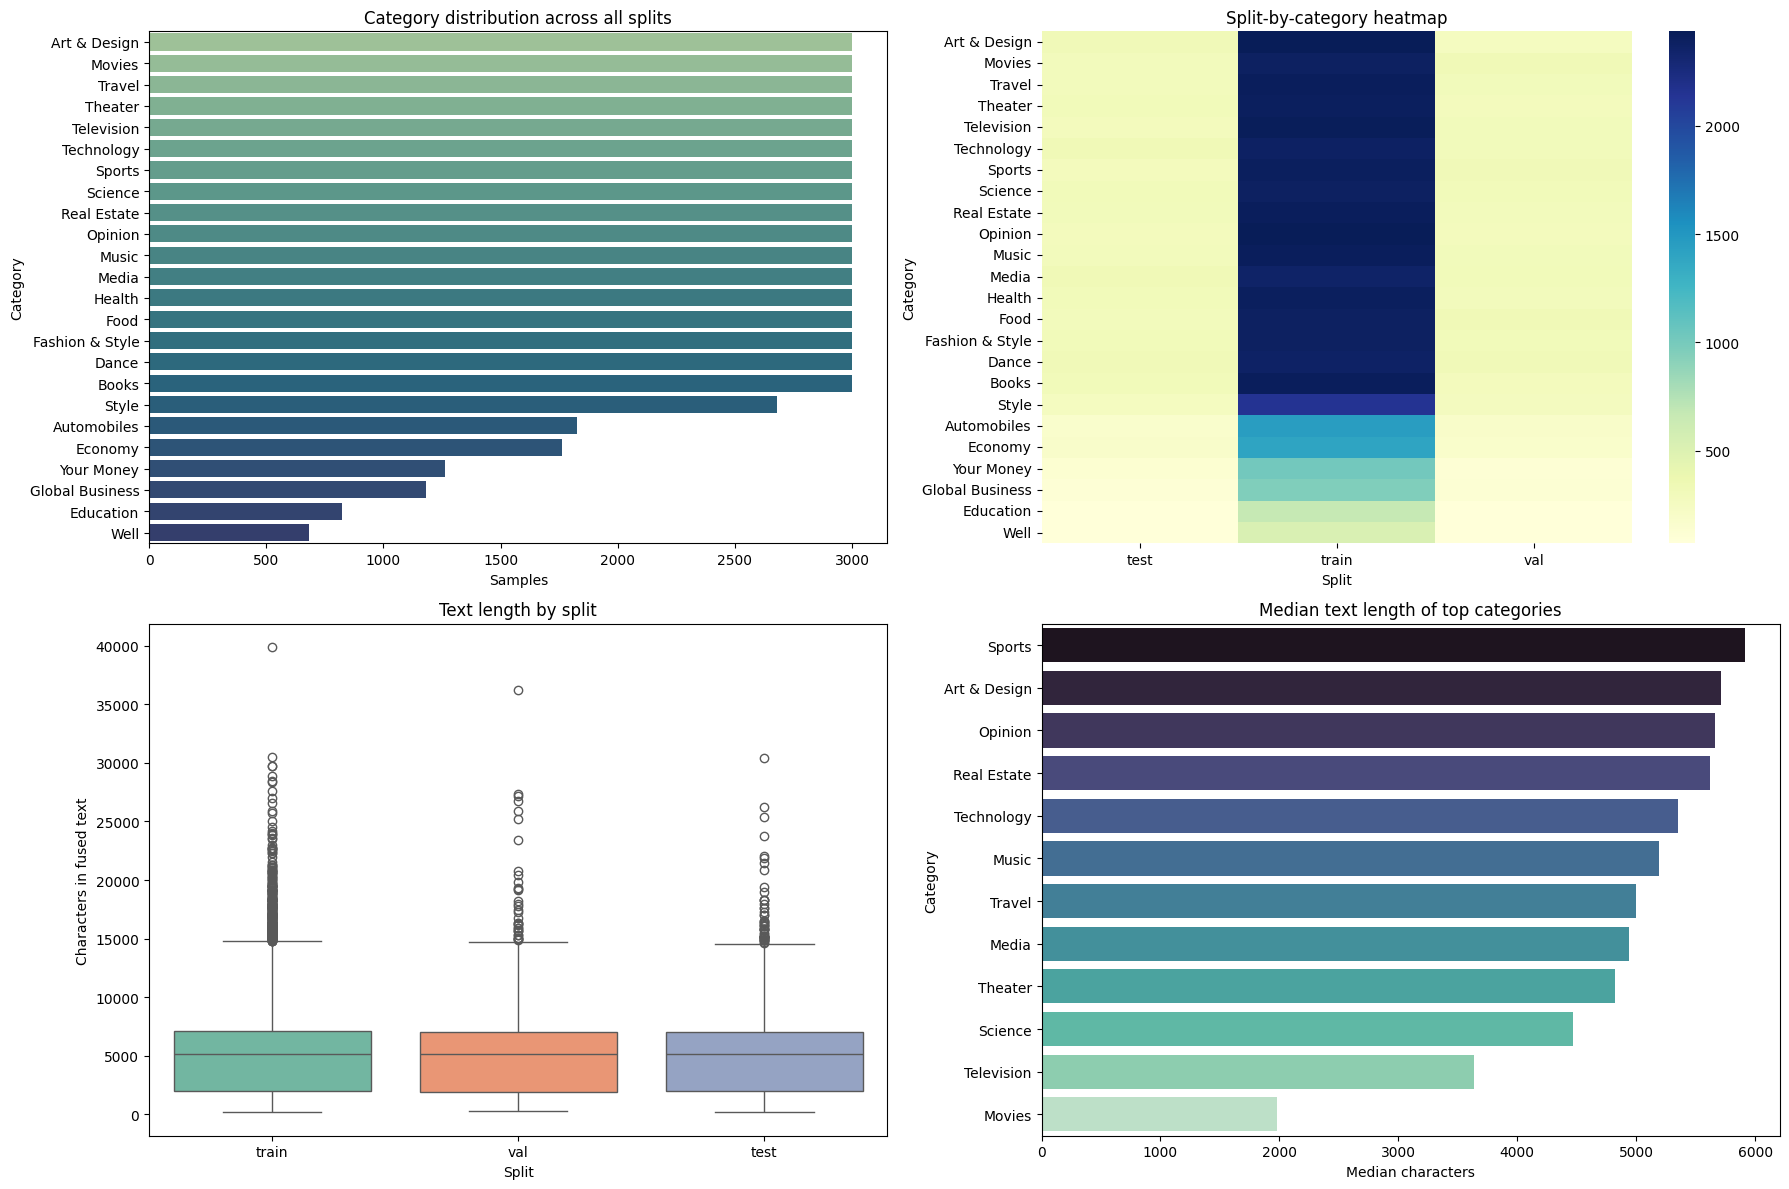

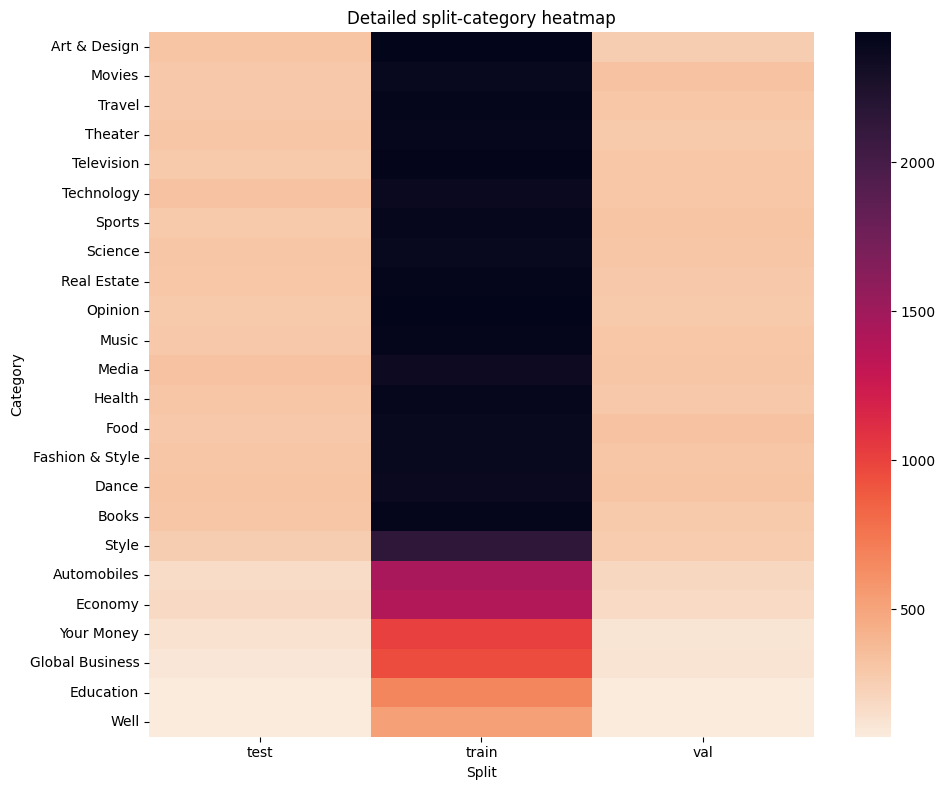

C:\Users\HAD\AppData\Local\Temp\ipykernel_31448\1933489236.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=length_summary_df, x="split", y="text_chars", inner="quartile", palette="Set2", ax=ax)


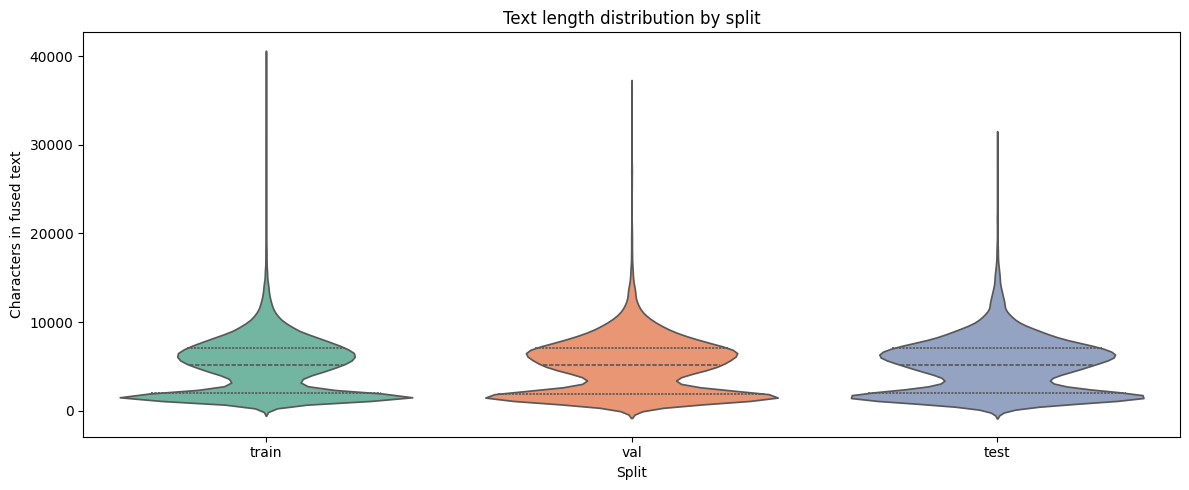

C:\Users\HAD\AppData\Local\Temp\ipykernel_31448\1933489236.py:94: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda frame: frame.sample(1, random_state=SEED))


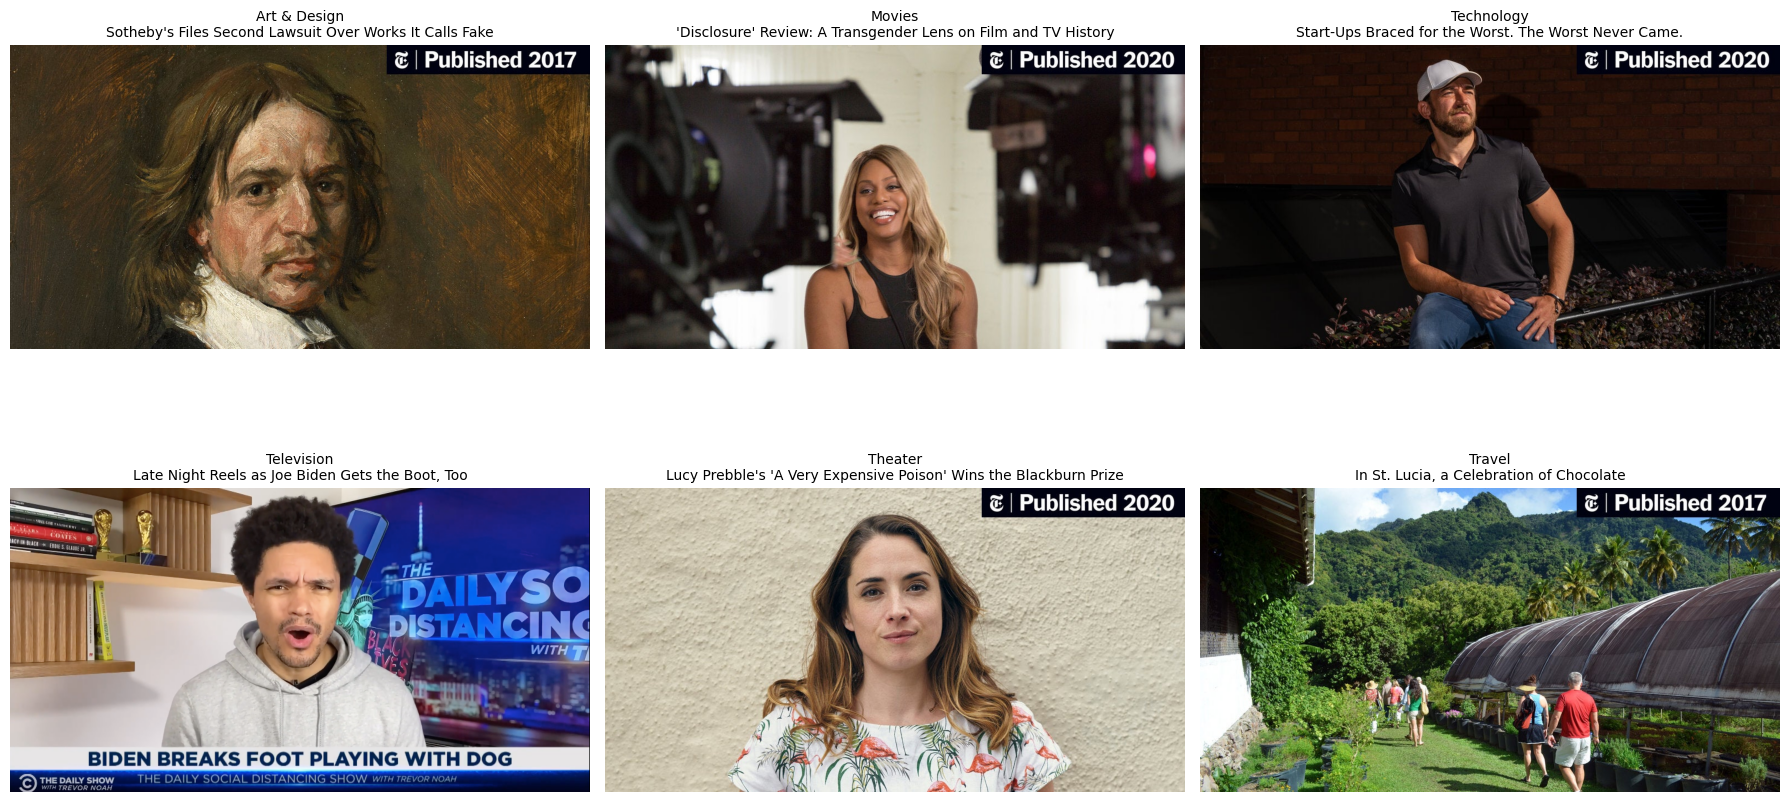

Saved label summary: D:\DeepLearning\btl1\artifacts\multimodal\n24news_label_summary.csv
Saved text summary: D:\DeepLearning\btl1\artifacts\multimodal\n24news_text_length_summary.csv
Saved EDA overview: D:\DeepLearning\btl1\artifacts\multimodal\n24news_eda_overview.png
Saved EDA heatmap: D:\DeepLearning\btl1\artifacts\multimodal\n24news_split_category_heatmap.png
Saved EDA text-length plot: D:\DeepLearning\btl1\artifacts\multimodal\n24news_text_length_boxplot.png
Saved EDA sample grid: D:\DeepLearning\btl1\artifacts\multimodal\n24news_sample_grid.png


In [6]:
label_summary_rows = []
for split_name, frame in split_frames.items():
    counts = frame["category"].value_counts()
    for category, count in counts.items():
        label_summary_rows.append({"split": split_name, "category": category, "samples": int(count)})

label_summary_df = pd.DataFrame(label_summary_rows)
label_summary_path = ARTIFACT_DIR / "n24news_label_summary.csv"
label_summary_df.to_csv(label_summary_path, index=False)

length_summary_df = pd.concat(
    [frame.assign(split=split_name)[["split", "category", "text_chars"]] for split_name, frame in split_frames.items()],
    ignore_index=True,
)
length_summary_path = ARTIFACT_DIR / "n24news_text_length_summary.csv"
length_summary_df.to_csv(length_summary_path, index=False)

combined_preview_df = pd.concat([
    train_df.assign(split="train"),
    val_df.assign(split="val"),
    test_df.assign(split="test"),
], ignore_index=True)

category_totals = (
    label_summary_df.groupby("category", as_index=False)["samples"]
    .sum()
    .sort_values("samples", ascending=False)
)
heatmap_df = (
    label_summary_df.pivot(index="category", columns="split", values="samples")
    .fillna(0)
    .astype(int)
    .loc[category_totals["category"].tolist()]
)
top_categories = category_totals.head(12)["category"].tolist()
text_median_df = (
    length_summary_df[length_summary_df["category"].isin(top_categories)]
    .groupby("category", as_index=False)["text_chars"]
    .median()
    .sort_values("text_chars", ascending=False)
)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
sns.barplot(data=category_totals, x="samples", y="category", ax=axes[0, 0], palette="crest")
axes[0, 0].set_title("Category distribution across all splits")
axes[0, 0].set_xlabel("Samples")
axes[0, 0].set_ylabel("Category")

sns.heatmap(heatmap_df, cmap="YlGnBu", annot=False, ax=axes[0, 1])
axes[0, 1].set_title("Split-by-category heatmap")
axes[0, 1].set_xlabel("Split")
axes[0, 1].set_ylabel("Category")

sns.boxplot(data=length_summary_df, x="split", y="text_chars", ax=axes[1, 0], palette="Set2")
axes[1, 0].set_title("Text length by split")
axes[1, 0].set_xlabel("Split")
axes[1, 0].set_ylabel("Characters in fused text")

sns.barplot(data=text_median_df, x="text_chars", y="category", ax=axes[1, 1], palette="mako")
axes[1, 1].set_title("Median text length of top categories")
axes[1, 1].set_xlabel("Median characters")
axes[1, 1].set_ylabel("Category")

fig.tight_layout()
eda_path = ARTIFACT_DIR / "n24news_eda_overview.png"
fig.savefig(eda_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close(fig)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(heatmap_df, cmap="rocket_r", annot=False, ax=ax)
ax.set_title("Detailed split-category heatmap")
ax.set_xlabel("Split")
ax.set_ylabel("Category")
heatmap_path = ARTIFACT_DIR / "n24news_split_category_heatmap.png"
fig.tight_layout()
fig.savefig(heatmap_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close(fig)

fig, ax = plt.subplots(figsize=(12, 5))
sns.violinplot(data=length_summary_df, x="split", y="text_chars", inner="quartile", palette="Set2", ax=ax)
ax.set_title("Text length distribution by split")
ax.set_xlabel("Split")
ax.set_ylabel("Characters in fused text")
length_plot_path = ARTIFACT_DIR / "n24news_text_length_boxplot.png"
fig.tight_layout()
fig.savefig(length_plot_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close(fig)

sample_rows = (
    combined_preview_df.groupby("category", group_keys=False)
    .apply(lambda frame: frame.sample(1, random_state=SEED))
    .reset_index(drop=True)
    .merge(category_totals.head(6)[["category"]], on="category")
)
sample_rows = sample_rows.sort_values("category").reset_index(drop=True)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for ax, (_, row) in zip(axes, sample_rows.iterrows()):
    image = Image.open(REPO_ROOT / row["image_relpath"]).convert("RGB")
    ax.imshow(image)
    title = row["headline"] if isinstance(row["headline"], str) and row["headline"].strip() else row["category"]
    if len(title) > 65:
        title = title[:62] + "..."
    ax.set_title(f"{row['category']}\n{title}", fontsize=10)
    ax.axis("off")
for ax in axes[len(sample_rows):]:
    ax.axis("off")
sample_grid_path = ARTIFACT_DIR / "n24news_sample_grid.png"
fig.tight_layout()
fig.savefig(sample_grid_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close(fig)

print(f"Saved label summary: {label_summary_path}")
print(f"Saved text summary: {length_summary_path}")
print(f"Saved EDA overview: {eda_path}")
print(f"Saved EDA heatmap: {heatmap_path}")
print(f"Saved EDA text-length plot: {length_plot_path}")
print(f"Saved EDA sample grid: {sample_grid_path}")


### Create Dataset Objects And Batch Builders

Cell này chuyển các CSV đã xử lý thành `PyTorch Dataset` và chuẩn bị hai luồng collate riêng cho `CLIP` và `VisualBERT`.


In [7]:
class N24NewsDataset(Dataset):
    def __init__(self, frame: pd.DataFrame):
        self.frame = frame.reset_index(drop=True)

    def __len__(self) -> int:
        return len(self.frame)

    def __getitem__(self, index: int):
        row = self.frame.iloc[index]
        image_path = REPO_ROOT / row["image_relpath"]
        with Image.open(image_path) as image:
            image = image.convert("RGB")
        return {
            "article_id": row["article_id"],
            "image": image,
            "text": row["text_input"],
            "label_id": int(row["label_id"]),
        }


clip_processor = AutoProcessor.from_pretrained(CLIP_CFG["backbone"])
vision_processor = AutoImageProcessor.from_pretrained(VB_CFG["vision_backbone"])
tokenizer = AutoTokenizer.from_pretrained(VB_CFG["tokenizer_name"])

train_dataset = N24NewsDataset(train_df)
val_dataset = N24NewsDataset(val_df)
test_dataset = N24NewsDataset(test_df)


def clip_collate(batch: list[dict]) -> tuple[dict, torch.Tensor]:
    images = [item["image"] for item in batch]
    texts = [item["text"] for item in batch]
    labels = torch.tensor([item["label_id"] for item in batch], dtype=torch.long)
    encoded = clip_processor(
        text=texts,
        images=images,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=CLIP_CFG["max_text_length"],
    )
    return encoded, labels


def visualbert_collate(batch: list[dict]) -> tuple[dict, torch.Tensor]:
    images = [item["image"] for item in batch]
    texts = [item["text"] for item in batch]
    labels = torch.tensor([item["label_id"] for item in batch], dtype=torch.long)

    text_inputs = tokenizer(
        texts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=VB_CFG["max_text_length"],
    )
    pixel_values = vision_processor(images=images, return_tensors="pt")["pixel_values"]
    batch_inputs = {
        "input_ids": text_inputs["input_ids"],
        "attention_mask": text_inputs["attention_mask"],
        "token_type_ids": text_inputs.get("token_type_ids", torch.zeros_like(text_inputs["input_ids"])),
        "pixel_values": pixel_values,
    }
    return batch_inputs, labels


def make_loader(dataset: Dataset, batch_size: int, collate_fn, shuffle: bool) -> DataLoader:
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
        collate_fn=collate_fn,
    )


print("Train dataset size:", len(train_dataset))
print("Validation dataset size:", len(val_dataset))
print("Test dataset size:", len(test_dataset))


C:\Users\HAD\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Train dataset size: 48988
Validation dataset size: 6123
Test dataset size: 6124


### Define The CLIP And VisualBERT Classifiers

Cell này bọc backbone pretrained bằng classification head để cả hai mô hình cùng giải bài toán news classification trên `N24News`.


In [8]:
class CLIPClassifier(nn.Module):
    def __init__(self, backbone: str, num_labels: int, dropout: float):
        super().__init__()
        self.backbone = CLIPModel.from_pretrained(backbone)
        hidden_size = self.backbone.config.projection_dim
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_size * 2, num_labels)

    def forward(self, input_ids, attention_mask, pixel_values):
        image_features = self.backbone.get_image_features(pixel_values=pixel_values)
        text_features = self.backbone.get_text_features(
            input_ids=input_ids,
            attention_mask=attention_mask,
        )
        image_features = nn.functional.normalize(image_features, dim=-1)
        text_features = nn.functional.normalize(text_features, dim=-1)
        fused = torch.cat([image_features, text_features], dim=-1)
        return self.classifier(self.dropout(fused))


class VisualBERTClassifier(nn.Module):
    def __init__(self, visualbert_backbone: str, vision_backbone: str, num_labels: int, dropout: float, max_visual_tokens: int):
        super().__init__()
        self.vision_encoder = CLIPVisionModel.from_pretrained(vision_backbone)
        config = VisualBertConfig.from_pretrained(visualbert_backbone)
        config.visual_embedding_dim = self.vision_encoder.config.hidden_size
        self.backbone = VisualBertModel.from_pretrained(visualbert_backbone, config=config, ignore_mismatched_sizes=True)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(config.hidden_size, num_labels)
        self.max_visual_tokens = max_visual_tokens

    def forward(self, input_ids, attention_mask, token_type_ids, pixel_values):
        visual_outputs = self.vision_encoder(pixel_values=pixel_values, return_dict=True)
        visual_embeds = visual_outputs.last_hidden_state[:, 1 : 1 + self.max_visual_tokens, :]
        batch_size, visual_tokens, _ = visual_embeds.shape
        visual_attention_mask = torch.ones((batch_size, visual_tokens), dtype=torch.long, device=visual_embeds.device)
        visual_token_type_ids = torch.ones((batch_size, visual_tokens), dtype=torch.long, device=visual_embeds.device)

        outputs = self.backbone(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
            visual_embeds=visual_embeds,
            visual_attention_mask=visual_attention_mask,
            visual_token_type_ids=visual_token_type_ids,
            return_dict=True,
        )
        pooled = outputs.pooler_output if outputs.pooler_output is not None else outputs.last_hidden_state[:, 0]
        return self.classifier(self.dropout(pooled))


### Train, Validate, And Evaluate The Models

Cell này gom logic huấn luyện, đánh giá trên tập `val`, early stopping, lưu checkpoint và đo kết quả cuối trên tập `test`.


In [9]:
def move_batch_to_device(batch_inputs: dict, labels: torch.Tensor) -> tuple[dict, torch.Tensor]:
    batch_inputs = {key: value.to(DEVICE) for key, value in batch_inputs.items()}
    labels = labels.to(DEVICE)
    return batch_inputs, labels


def collect_predictions(model: nn.Module, loader: DataLoader, criterion: nn.Module) -> tuple[float, np.ndarray, np.ndarray]:
    model.eval()
    total_loss = 0.0
    total_examples = 0
    logits_list = []
    labels_list = []

    with torch.no_grad():
        for batch_inputs, labels in loader:
            batch_inputs, labels = move_batch_to_device(batch_inputs, labels)
            logits = model(**batch_inputs)
            loss = criterion(logits, labels)
            batch_size = labels.size(0)
            total_loss += loss.item() * batch_size
            total_examples += batch_size
            logits_list.append(logits.detach().cpu().numpy())
            labels_list.append(labels.detach().cpu().numpy())

    mean_loss = total_loss / max(total_examples, 1)
    logits_np = np.concatenate(logits_list, axis=0)
    labels_np = np.concatenate(labels_list, axis=0)
    return mean_loss, logits_np, labels_np


def compute_metrics(logits: np.ndarray, labels: np.ndarray, label_names: list[str]) -> tuple[dict, pd.DataFrame, np.ndarray]:
    predictions = logits.argmax(axis=1)
    metrics = {
        "accuracy": float(accuracy_score(labels, predictions)),
        "macro_f1": float(f1_score(labels, predictions, average="macro", zero_division=0)),
        "weighted_f1": float(f1_score(labels, predictions, average="weighted", zero_division=0)),
    }
    per_label_f1 = f1_score(labels, predictions, average=None, labels=list(range(len(label_names))), zero_division=0)
    support = pd.Series(labels).value_counts().reindex(range(len(label_names)), fill_value=0).to_numpy()
    per_label_df = pd.DataFrame(
        {
            "category": label_names,
            "f1": per_label_f1,
            "support": support.astype(int),
        }
    )
    cm = confusion_matrix(labels, predictions, labels=list(range(len(label_names))))
    return metrics, per_label_df, cm


def plot_history(history_df: pd.DataFrame, model_name: str) -> Path:
    figure_path = ARTIFACT_DIR / f"n24news_{model_name.lower()}_history.png"
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].plot(history_df["epoch"], history_df["train_loss"], marker="o", label="train")
    axes[0].plot(history_df["epoch"], history_df["val_loss"], marker="o", label="val")
    axes[0].set_title(f"{model_name} loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(history_df["epoch"], history_df["val_accuracy"], marker="o", label="val accuracy")
    axes[1].plot(history_df["epoch"], history_df["val_macro_f1"], marker="o", label="val macro F1")
    axes[1].set_title(f"{model_name} validation metrics")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Score")
    axes[1].legend()

    fig.tight_layout()
    fig.savefig(figure_path, dpi=180, bbox_inches="tight")
    plt.close(fig)
    return figure_path


def plot_confusion(cm: np.ndarray, model_name: str, label_names: list[str]) -> Path:
    figure_path = ARTIFACT_DIR / f"n24news_{model_name.lower()}_confusion_matrix.png"
    fig, ax = plt.subplots(figsize=(14, 12))
    sns.heatmap(cm, cmap="Blues", ax=ax, square=False)
    ax.set_title(f"{model_name} confusion matrix")
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_xticks(np.arange(len(label_names)) + 0.5)
    ax.set_xticklabels(label_names, rotation=90)
    ax.set_yticks(np.arange(len(label_names)) + 0.5)
    ax.set_yticklabels(label_names, rotation=0)
    fig.tight_layout()
    fig.savefig(figure_path, dpi=180, bbox_inches="tight")
    plt.close(fig)
    return figure_path


def train_model(model_name: str, model: nn.Module, train_loader: DataLoader, val_loader: DataLoader, cfg: dict) -> dict:
    checkpoint_path = ARTIFACT_DIR / f"n24news_{model_name.lower()}_best.pt"
    history_path = ARTIFACT_DIR / f"n24news_{model_name.lower()}_history.csv"
    reuse_checkpoint = REUSE_CHECKPOINT_IF_AVAILABLE and checkpoint_path.exists()

    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = None
    scheduler = None
    scaler = None
    if not reuse_checkpoint:
        optimizer = AdamW(model.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"])
        total_steps = max(1, len(train_loader) * cfg["epochs"])
        warmup_steps = max(1, int(total_steps * cfg["warmup_ratio"]))
        scheduler = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)
        scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

    best_macro_f1 = -1.0
    patience_left = cfg["patience"]
    history_rows = []

    if reuse_checkpoint:
        print(f"Reusing existing checkpoint for {model_name}. Training loop is skipped.")
    else:
        for epoch in range(1, cfg["epochs"] + 1):
            model.train()
            train_loss = 0.0
            train_examples = 0

            for batch_inputs, labels in tqdm(train_loader, desc=f"{model_name} epoch {epoch}"):
                batch_inputs, labels = move_batch_to_device(batch_inputs, labels)
                optimizer.zero_grad(set_to_none=True)
                with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
                    logits = model(**batch_inputs)
                    loss = criterion(logits, labels)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()

                batch_size = labels.size(0)
                train_loss += loss.item() * batch_size
                train_examples += batch_size

            train_loss /= max(train_examples, 1)
            val_loss, val_logits, val_labels = collect_predictions(model, val_loader, criterion)
            val_metrics, _, _ = compute_metrics(val_logits, val_labels, label_names)

            history_rows.append(
                {
                    "epoch": epoch,
                    "train_loss": train_loss,
                    "val_loss": val_loss,
                    "val_accuracy": val_metrics["accuracy"],
                    "val_macro_f1": val_metrics["macro_f1"],
                    "val_weighted_f1": val_metrics["weighted_f1"],
                }
            )

            print(
                f"{model_name} | epoch {epoch} | train_loss={train_loss:.4f} | "
                f"val_loss={val_loss:.4f} | val_accuracy={val_metrics['accuracy']:.4f} | "
                f"val_macro_f1={val_metrics['macro_f1']:.4f}"
            )

            if val_metrics["macro_f1"] > best_macro_f1:
                best_macro_f1 = val_metrics["macro_f1"]
                patience_left = cfg["patience"]
                torch.save(
                    {
                        "model_state_dict": model.state_dict(),
                        "label_names": label_names,
                        "config": cfg,
                    },
                    checkpoint_path,
                )
            else:
                patience_left -= 1
                if patience_left <= 0:
                    print(f"Early stopping triggered for {model_name}.")
                    break

    if history_rows:
        history_df = pd.DataFrame(history_rows)
        history_df.to_csv(history_path, index=False)
    elif history_path.exists():
        history_df = pd.read_csv(history_path)
        history_df = history_df.rename(
            columns={
                "dev_loss": "val_loss",
                "dev_accuracy": "val_accuracy",
                "dev_macro_f1": "val_macro_f1",
                "dev_weighted_f1": "val_weighted_f1",
            }
        )
        history_df.to_csv(history_path, index=False)
    else:
        history_df = pd.DataFrame(columns=["epoch", "train_loss", "val_loss", "val_accuracy", "val_macro_f1", "val_weighted_f1"])

    history_figure = plot_history(history_df, model_name) if not history_df.empty else None

    checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    val_loss, val_logits, val_labels = collect_predictions(model, val_loader, criterion)
    val_metrics, val_per_label, val_cm = compute_metrics(val_logits, val_labels, label_names)

    test_loader = train_model.test_loader_lookup[model_name]
    test_loss, test_logits, test_labels = collect_predictions(model, test_loader, criterion)
    test_metrics, test_per_label, test_cm = compute_metrics(test_logits, test_labels, label_names)
    test_metrics["loss"] = float(test_loss)

    confusion_path = plot_confusion(test_cm, model_name, label_names)

    return {
        "model_name": model_name,
        "checkpoint_path": checkpoint_path,
        "history_path": history_path,
        "history_figure": history_figure,
        "history_df": history_df,
        "val_metrics": val_metrics,
        "val_per_label": val_per_label,
        "val_confusion": val_cm,
        "test_metrics": test_metrics,
        "test_per_label": test_per_label,
        "test_confusion": test_cm,
        "test_logits": test_logits,
        "test_labels": test_labels,
        "test_predictions": test_logits.argmax(axis=1),
        "confusion_path": confusion_path,
    }


train_model.test_loader_lookup = {}


### Fine-Tune CLIP

Cell này huấn luyện `CLIP` trên split của `N24News` và trả về metric cuối trên tập test.


In [10]:
clip_train_loader = make_loader(train_dataset, CLIP_CFG["batch_size"], clip_collate, shuffle=True)
clip_val_loader = make_loader(val_dataset, CLIP_CFG["batch_size"], clip_collate, shuffle=False)
clip_test_loader = make_loader(test_dataset, CLIP_CFG["batch_size"], clip_collate, shuffle=False)
train_model.test_loader_lookup["CLIP"] = clip_test_loader

clip_model = CLIPClassifier(
    backbone=CLIP_CFG["backbone"],
    num_labels=len(label_names),
    dropout=CLIP_CFG["dropout"],
)

clip_result = train_model("CLIP", clip_model, clip_train_loader, clip_val_loader, CLIP_CFG)
clip_result["test_metrics"]


Reusing existing checkpoint for CLIP. Training loop is skipped.


{'accuracy': 0.848791639451339,
 'macro_f1': 0.8063637712893706,
 'weighted_f1': 0.8346101567155595,
 'loss': 1.9986581727619035}

### Fine-Tune VisualBERT

Cell này huấn luyện `VisualBERT` trên cùng protocol để so sánh công bằng với `CLIP`.


In [11]:
vb_train_loader = make_loader(train_dataset, VB_CFG["batch_size"], visualbert_collate, shuffle=True)
vb_val_loader = make_loader(val_dataset, VB_CFG["batch_size"], visualbert_collate, shuffle=False)
vb_test_loader = make_loader(test_dataset, VB_CFG["batch_size"], visualbert_collate, shuffle=False)
train_model.test_loader_lookup["VisualBERT"] = vb_test_loader

visualbert_model = VisualBERTClassifier(
    visualbert_backbone=VB_CFG["visualbert_backbone"],
    vision_backbone=VB_CFG["vision_backbone"],
    num_labels=len(label_names),
    dropout=VB_CFG["dropout"],
    max_visual_tokens=VB_CFG["max_visual_tokens"],
)

visualbert_result = train_model("VisualBERT", visualbert_model, vb_train_loader, vb_val_loader, VB_CFG)
visualbert_result["test_metrics"]


Some weights of VisualBertModel were not initialized from the model checkpoint at uclanlp/visualbert-vqa-coco-pre and are newly initialized because the shapes did not match:
- visual_bert.embeddings.visual_projection.weight: found shape torch.Size([768, 2048]) in the checkpoint and torch.Size([768, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Reusing existing checkpoint for VisualBERT. Training loop is skipped.


{'accuracy': 0.8750816459830176,
 'macro_f1': 0.8574857709215573,
 'weighted_f1': 0.8732028740467108,
 'loss': 0.3977566836103748}

### Export Metrics And Visualizations

Cell cuối cùng tổng hợp metric, per-class F1 và các file CSV/JSON/PNG để phục vụ báo cáo.


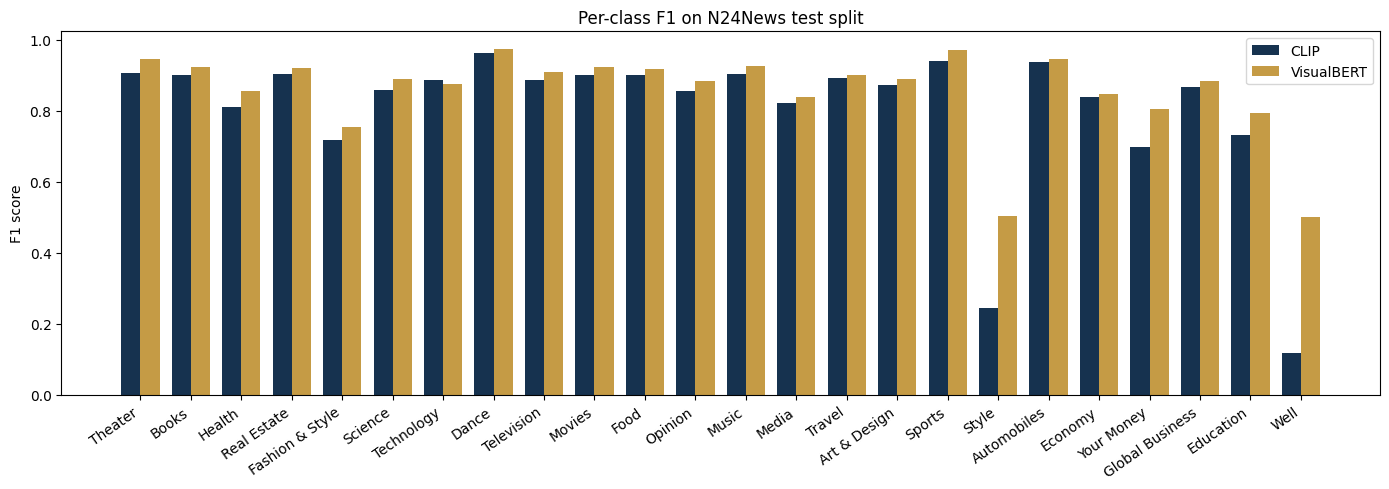

Saved comparison file: D:\DeepLearning\btl1\artifacts\multimodal\n24news_model_comparison.csv
Saved metrics summary: D:\DeepLearning\btl1\artifacts\multimodal\n24news_metrics_summary.json
Saved per-class F1 file: D:\DeepLearning\btl1\artifacts\multimodal\n24news_per_label_f1.csv
Saved per-class F1 figure: D:\DeepLearning\btl1\artifacts\multimodal\n24news_per_label_f1.png
Saved CLIP confusion matrix: D:\DeepLearning\btl1\artifacts\multimodal\n24news_clip_confusion_matrix.png
Saved VisualBERT confusion matrix: D:\DeepLearning\btl1\artifacts\multimodal\n24news_visualbert_confusion_matrix.png


,model,accuracy,macro_f1,weighted_f1,loss
1,VisualBERT,0.875082,0.857486,0.873203,0.397757
0,CLIP,0.848792,0.806364,0.834610,1.998658


In [12]:
comparison_rows = []
for result in [clip_result, visualbert_result]:
    row = {
        "model": result["model_name"],
        **result["test_metrics"],
    }
    comparison_rows.append(row)

comparison_df = pd.DataFrame(comparison_rows).sort_values(["macro_f1", "accuracy"], ascending=False)
comparison_path = ARTIFACT_DIR / "n24news_model_comparison.csv"
comparison_df.to_csv(comparison_path, index=False)

metrics_summary = {
    "dataset": "N24News",
    "task": "image + news text -> category classification",
    "split_sizes": {split_name: int(len(frame)) for split_name, frame in split_frames.items()},
    "num_classes": len(label_names),
    "label_names": label_names,
    "models": {
        "CLIP": clip_result["test_metrics"],
        "VisualBERT": visualbert_result["test_metrics"],
    },
    "sources": {
        "official_repo": OFFICIAL_REPO_URL,
        "paper": PAPER_URL,
        "drive": N24NEWS_DRIVE_URL,
    },
}
metrics_summary_path = ARTIFACT_DIR / "n24news_metrics_summary.json"
metrics_summary_path.write_text(json.dumps(metrics_summary, indent=2, ensure_ascii=False), encoding="utf-8")

per_label_df = clip_result["test_per_label"].merge(
    visualbert_result["test_per_label"][["category", "f1"]],
    on="category",
    suffixes=("_clip", "_visualbert"),
)
per_label_path = ARTIFACT_DIR / "n24news_per_label_f1.csv"
per_label_df.to_csv(per_label_path, index=False)

fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(per_label_df))
width = 0.38
ax.bar(x - width / 2, per_label_df["f1_clip"], width=width, label="CLIP", color="#16324f")
ax.bar(x + width / 2, per_label_df["f1_visualbert"], width=width, label="VisualBERT", color="#c59b45")
ax.set_xticks(x)
ax.set_xticklabels(per_label_df["category"], rotation=35, ha="right")
ax.set_ylabel("F1 score")
ax.set_title("Per-class F1 on N24News test split")
ax.legend()
fig.tight_layout()
per_label_figure = ARTIFACT_DIR / "n24news_per_label_f1.png"
fig.savefig(per_label_figure, dpi=180, bbox_inches="tight")
plt.show()
plt.close(fig)

print("Saved comparison file:", comparison_path)
print("Saved metrics summary:", metrics_summary_path)
print("Saved per-class F1 file:", per_label_path)
print("Saved per-class F1 figure:", per_label_figure)
print("Saved CLIP confusion matrix:", clip_result["confusion_path"])
print("Saved VisualBERT confusion matrix:", visualbert_result["confusion_path"])
comparison_df


### Export Hard Cases For Report Review

Cell nay sinh mot nhom hard cases tu tap test that, copy anh preview vao `btl1/reports/media/n24news-hard-cases/` va ghi `manifest.json` de report web co the tai lap truc tiep tu notebook.


In [13]:
def softmax_numpy(logits: np.ndarray) -> np.ndarray:
    shifted = logits - logits.max(axis=1, keepdims=True)
    exp_values = np.exp(shifted)
    return exp_values / exp_values.sum(axis=1, keepdims=True)


hard_case_df = test_df.reset_index(drop=True).copy()
if len(hard_case_df) != len(clip_result["test_predictions"]) or len(hard_case_df) != len(visualbert_result["test_predictions"]):
    raise RuntimeError("Test dataframe and model predictions are misaligned.")

clip_probs = softmax_numpy(clip_result["test_logits"])
vb_probs = softmax_numpy(visualbert_result["test_logits"])

hard_case_df["clip_pred_id"] = clip_result["test_predictions"]
hard_case_df["vb_pred_id"] = visualbert_result["test_predictions"]
hard_case_df["clip_pred"] = [label_names[idx] for idx in hard_case_df["clip_pred_id"]]
hard_case_df["vb_pred"] = [label_names[idx] for idx in hard_case_df["vb_pred_id"]]
hard_case_df["clip_score"] = clip_probs.max(axis=1)
hard_case_df["vb_score"] = vb_probs.max(axis=1)
hard_case_df["clip_correct"] = hard_case_df["clip_pred_id"] == hard_case_df["label_id"]
hard_case_df["vb_correct"] = hard_case_df["vb_pred_id"] == hard_case_df["label_id"]
hard_case_df["f1_gain_proxy"] = hard_case_df["vb_score"] - hard_case_df["clip_score"]

def case_type(row: pd.Series) -> str:
    if (not row["clip_correct"]) and row["vb_correct"]:
        return "clip_wrong_visualbert_right"
    if (not row["clip_correct"]) and (not row["vb_correct"]):
        return "both_wrong"
    if row["clip_correct"] and (not row["vb_correct"]):
        return "clip_right_visualbert_wrong"
    return "both_correct"


hard_case_df["case_type"] = hard_case_df.apply(case_type, axis=1)
priority_map = {
    "clip_wrong_visualbert_right": 0,
    "both_wrong": 1,
    "clip_right_visualbert_wrong": 2,
    "both_correct": 3,
}
hard_case_df["priority"] = hard_case_df["case_type"].map(priority_map)

selected_frames = []
selected_ids = set()
for category in TAIL_FOCUS_CLASSES:
    category_frame = hard_case_df[hard_case_df["category"] == category].copy()
    if category_frame.empty:
        continue
    category_frame = category_frame.sort_values(["priority", "f1_gain_proxy", "vb_score"], ascending=[True, False, False])
    picked = category_frame.head(HARD_CASES_PER_CLASS).copy()
    selected_frames.append(picked)
    selected_ids.update(picked["article_id"].tolist())

hard_cases = pd.concat(selected_frames, ignore_index=True) if selected_frames else pd.DataFrame(columns=hard_case_df.columns)
if len(hard_cases) < len(TAIL_FOCUS_CLASSES) * HARD_CASES_PER_CLASS:
    fallback = hard_case_df[~hard_case_df["article_id"].isin(selected_ids)].copy()
    fallback = fallback.sort_values(["priority", "f1_gain_proxy", "vb_score"], ascending=[True, False, False])
    missing = len(TAIL_FOCUS_CLASSES) * HARD_CASES_PER_CLASS - len(hard_cases)
    hard_cases = pd.concat([hard_cases, fallback.head(max(missing, 0))], ignore_index=True)

hard_cases = hard_cases.reset_index(drop=True)
hard_case_csv_path = ARTIFACT_DIR / "n24news_hard_cases.csv"
hard_cases.to_csv(hard_case_csv_path, index=False)

HARD_CASE_DIR.mkdir(parents=True, exist_ok=True)
for old_file in HARD_CASE_DIR.iterdir():
    if old_file.is_file():
        old_file.unlink()

manifest_rows = []
for index, row in hard_cases.iterrows():
    source_image = REPO_ROOT / row["image_relpath"]
    suffix = source_image.suffix.lower() or ".jpg"
    slug = re.sub(r"[^a-z0-9]+", "-", str(row["category"]).lower()).strip("-")
    target_name = f"{index + 1:02d}-{slug}{suffix}"
    target_path = HARD_CASE_DIR / target_name
    shutil.copy2(source_image, target_path)

    title = row["headline"] if isinstance(row["headline"], str) and row["headline"].strip() else row["category"]
    preview = normalize_space(row["text_input"])
    if len(preview) > 220:
        preview = preview[:217] + "..."

    manifest_rows.append({
        "category": row["category"],
        "headline": title,
        "text_preview": preview,
        "image": f"./media/n24news-hard-cases/{target_name}?v={PREVIEW_VERSION}",
        "clip_pred": row["clip_pred"],
        "clip_score": round(float(row["clip_score"]), 4),
        "vb_pred": row["vb_pred"],
        "vb_score": round(float(row["vb_score"]), 4),
        "clip_correct": bool(row["clip_correct"]),
        "vb_correct": bool(row["vb_correct"]),
        "case_type": row["case_type"],
    })

HARD_CASE_MANIFEST_PATH.write_text(json.dumps(manifest_rows, indent=2, ensure_ascii=False), encoding="utf-8")
print("Saved hard-case CSV:", hard_case_csv_path)
print("Saved hard-case manifest:", HARD_CASE_MANIFEST_PATH)
print("Hard-case preview count:", len(manifest_rows))
pd.DataFrame(manifest_rows)


Saved hard-case CSV:

 D:\DeepLearning\btl1\artifacts\multimodal\n24news_hard_cases.csv
Saved hard-case manifest: D:\DeepLearning\btl1\reports\media\n24news-hard-cases\manifest.json
Hard-case preview count: 8


,category,headline,text_preview,image,clip_pred,clip_score,vb_pred,vb_score,clip_correct,vb_correct,case_type
0,Well,How to Do the Shortest Workout Possible,Headline: How to Do the Shortest Workout Possi...,./media/n24news-hard-cases/01-well.jpg?v=20260...,Television,0.0626,Well,0.8575,False,True,clip_wrong_visualbert_right
1,Well,Seeing Myself Through My Child's Eyes,Headline: Seeing Myself Through My Child's Eye...,./media/n24news-hard-cases/02-well.jpg?v=20260...,Health,0.0689,Well,0.8398,False,True,clip_wrong_visualbert_right
2,Style,'Avocado Toast' Is Now a Paint Color,Headline: 'Avocado Toast' Is Now a Paint Color...,./media/n24news-hard-cases/03-style.jpg?v=2026...,Art & Design,0.0827,Style,0.8798,False,True,clip_wrong_visualbert_right
3,Style,"Delayed Moves, Poolside Videos and Postmates S...","Headline: Delayed Moves, Poolside Videos and P...",./media/n24news-hard-cases/04-style.jpg?v=2026...,Fashion & Style,0.1125,Style,0.8959,False,True,clip_wrong_visualbert_right
4,Education,"Teachers' Unions Fight Standardized Testing, a...",Headline: Teachers' Unions Fight Standardized ...,./media/n24news-hard-cases/05-education.jpg?v=...,Opinion,0.0751,Education,0.9539,False,True,clip_wrong_visualbert_right
5,Education,"William E. Macaulay, 74, Booster of Tuition-Fr...","Headline: William E. Macaulay, 74, Booster of ...",./media/n24news-hard-cases/06-education.jpg?v=...,Art & Design,0.0722,Education,0.9268,False,True,clip_wrong_visualbert_right
6,Your Money,When White Diamonds Won't Cut It,Headline: When White Diamonds Won't Cut It Abs...,./media/n24news-hard-cases/07-your-money.jpg?v...,Fashion & Style,0.0727,Your Money,0.9689,False,True,clip_wrong_visualbert_right
7,Your Money,How to Apply for the Public Service Loan Forgi...,Headline: How to Apply for the Public Service ...,./media/n24news-hard-cases/08-your-money.jpg?v...,Television,0.0736,Your Money,0.9627,False,True,clip_wrong_visualbert_right
